In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
from plotly import graph_objs as go
import plotly.express as px
import plotly.figure_factory as ff
from wordcloud import STOPWORDS
from collections import defaultdict
import random
import re
import string

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
df.sample(5)

,id,keyword,location,text,target
6025,8610,seismic,"Lakewood, Tennessee",'Seismic' Apple TV service to stream 25 channe...,0
4791,6815,loud%20bang,Photo : Blue Mountains,#auspol Can you see the resemblance between AB...,0
2261,3241,deluged,NaN,@accionempresa The U.S. Department of Commerce...,0
3723,5293,fear,Alliston Ontario,@ScottDPierce @billharris_tv @HarrisGle @Beeze...,0
6096,8705,sinking,NaN,Currency transgress before payday-prison ward ...,0


In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
class_names =['Not a disaster', 'Disaster']

In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
# word_count
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# unique_word_count
df['unique_word_count'] = df['text'].apply(lambda x: len(set(str(x).split())))

# stop_word_count
df['stop_word_count'] = df['text'].apply(lambda x: len([w for w in str(x).lower().split() if w in STOPWORDS]))

# url_count
df['url_count'] = df['text'].apply(lambda x: len([w for w in str(x).lower().split() if 'http' in w or 'https' in w]))

# mean_word_length
df['mean_word_length'] = df['text'].apply(lambda x: np.mean([len(w) for w in str(x).split()]))

# char_count
df['char_count'] = df['text'].apply(lambda x: len(str(x)))

# punctuation_count
df['punctuation_count'] = df['text'].apply(lambda x: len([c for c in str(x) if c in string.punctuation]))

# hashtag_count
df['hashtag_count'] = df['text'].apply(lambda x: len([c for c in str(x) if c == '#']))

# mention_count
df['mention_count'] = df['text'].apply(lambda x: len([c for c in str(x) if c == '@']))

Text(0.5, 1.0, 'Number of punctuations in each class')

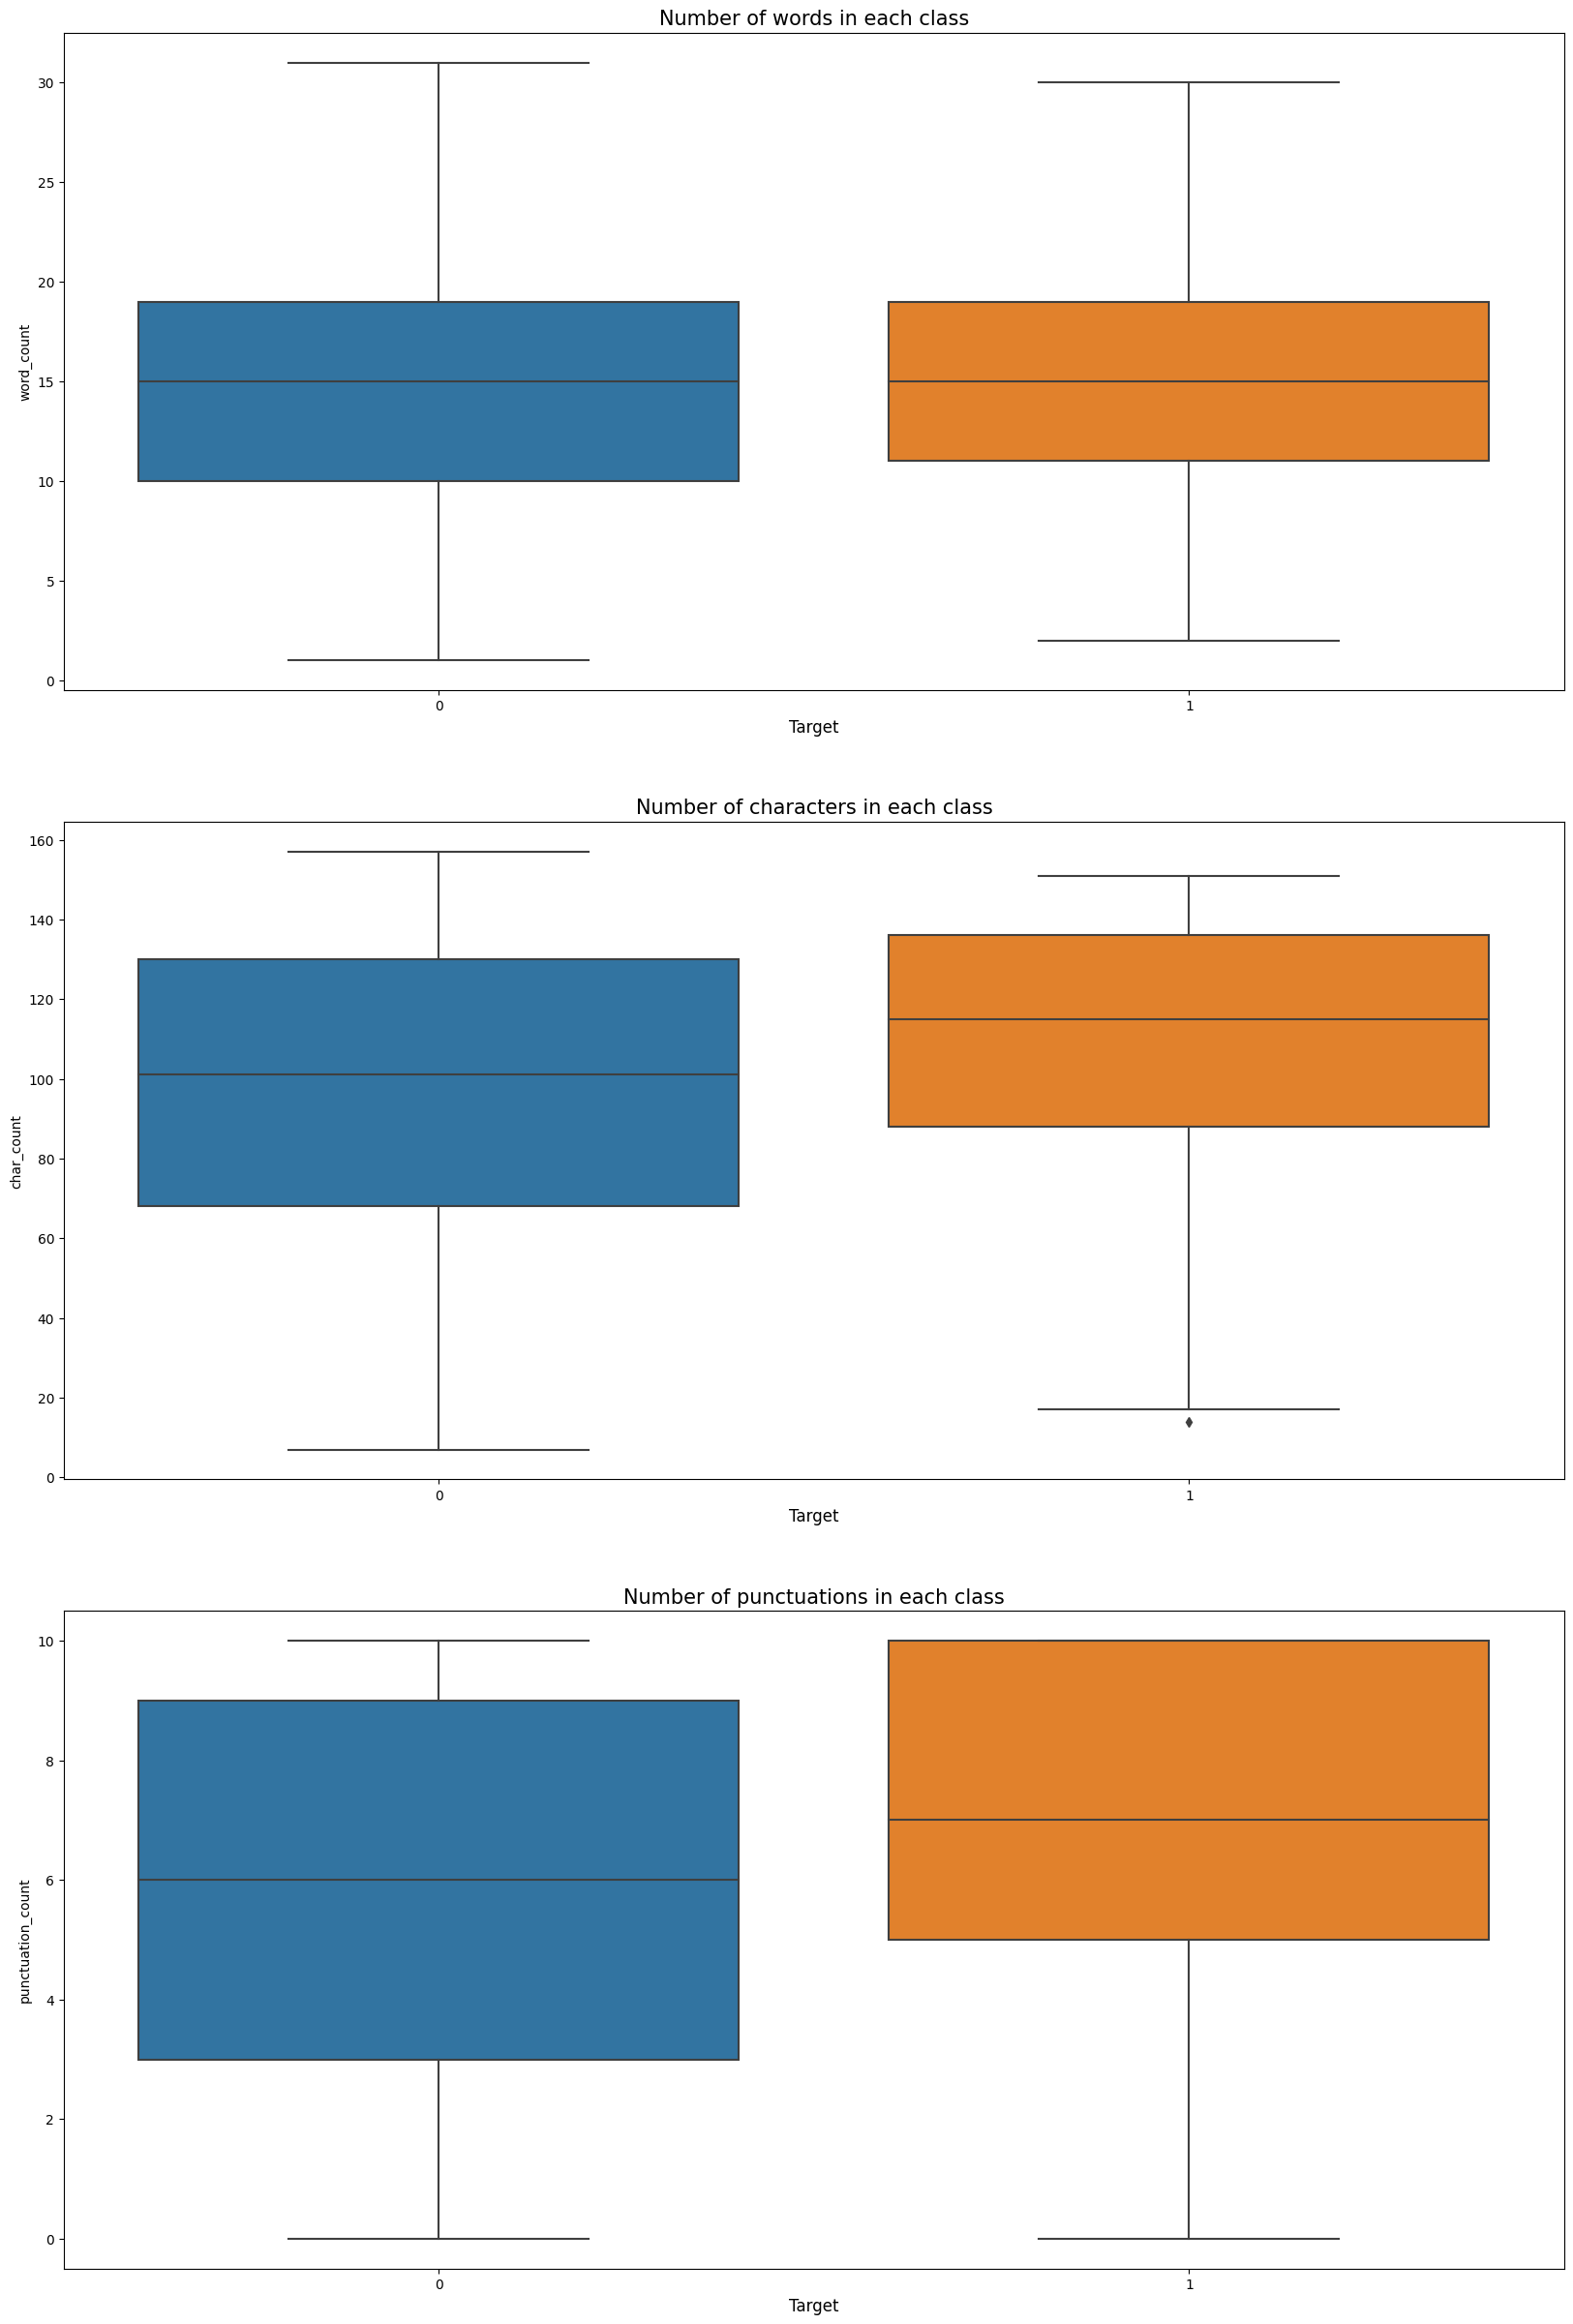

In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
## Truncate some extreme values for better visuals ##
df['word_count'].loc[df['word_count']>60] = 60 #truncation for better visuals
df['char_count'].loc[df['char_count']>350] = 350 #truncation for better visuals
df['punctuation_count'].loc[df['punctuation_count']>10] = 10 #truncation for better visuals

f, axes = plt.subplots(3, 1, figsize=(20,30))
sns.boxplot(x='target', y='word_count', data=df, ax=axes[0])
axes[0].set_xlabel('Target', fontsize=12)
axes[0].set_title("Number of words in each class", fontsize=15)

sns.boxplot(x='target', y='char_count', data=df, ax=axes[1])
axes[1].set_xlabel('Target', fontsize=12)
axes[1].set_title("Number of characters in each class", fontsize=15)

sns.boxplot(x='target', y='punctuation_count', data=df, ax=axes[2])
axes[2].set_xlabel('Target', fontsize=12)
#plt.ylabel('Number of punctuations in text', fontsize=12)
axes[2].set_title("Number of punctuations in each class", fontsize=15)

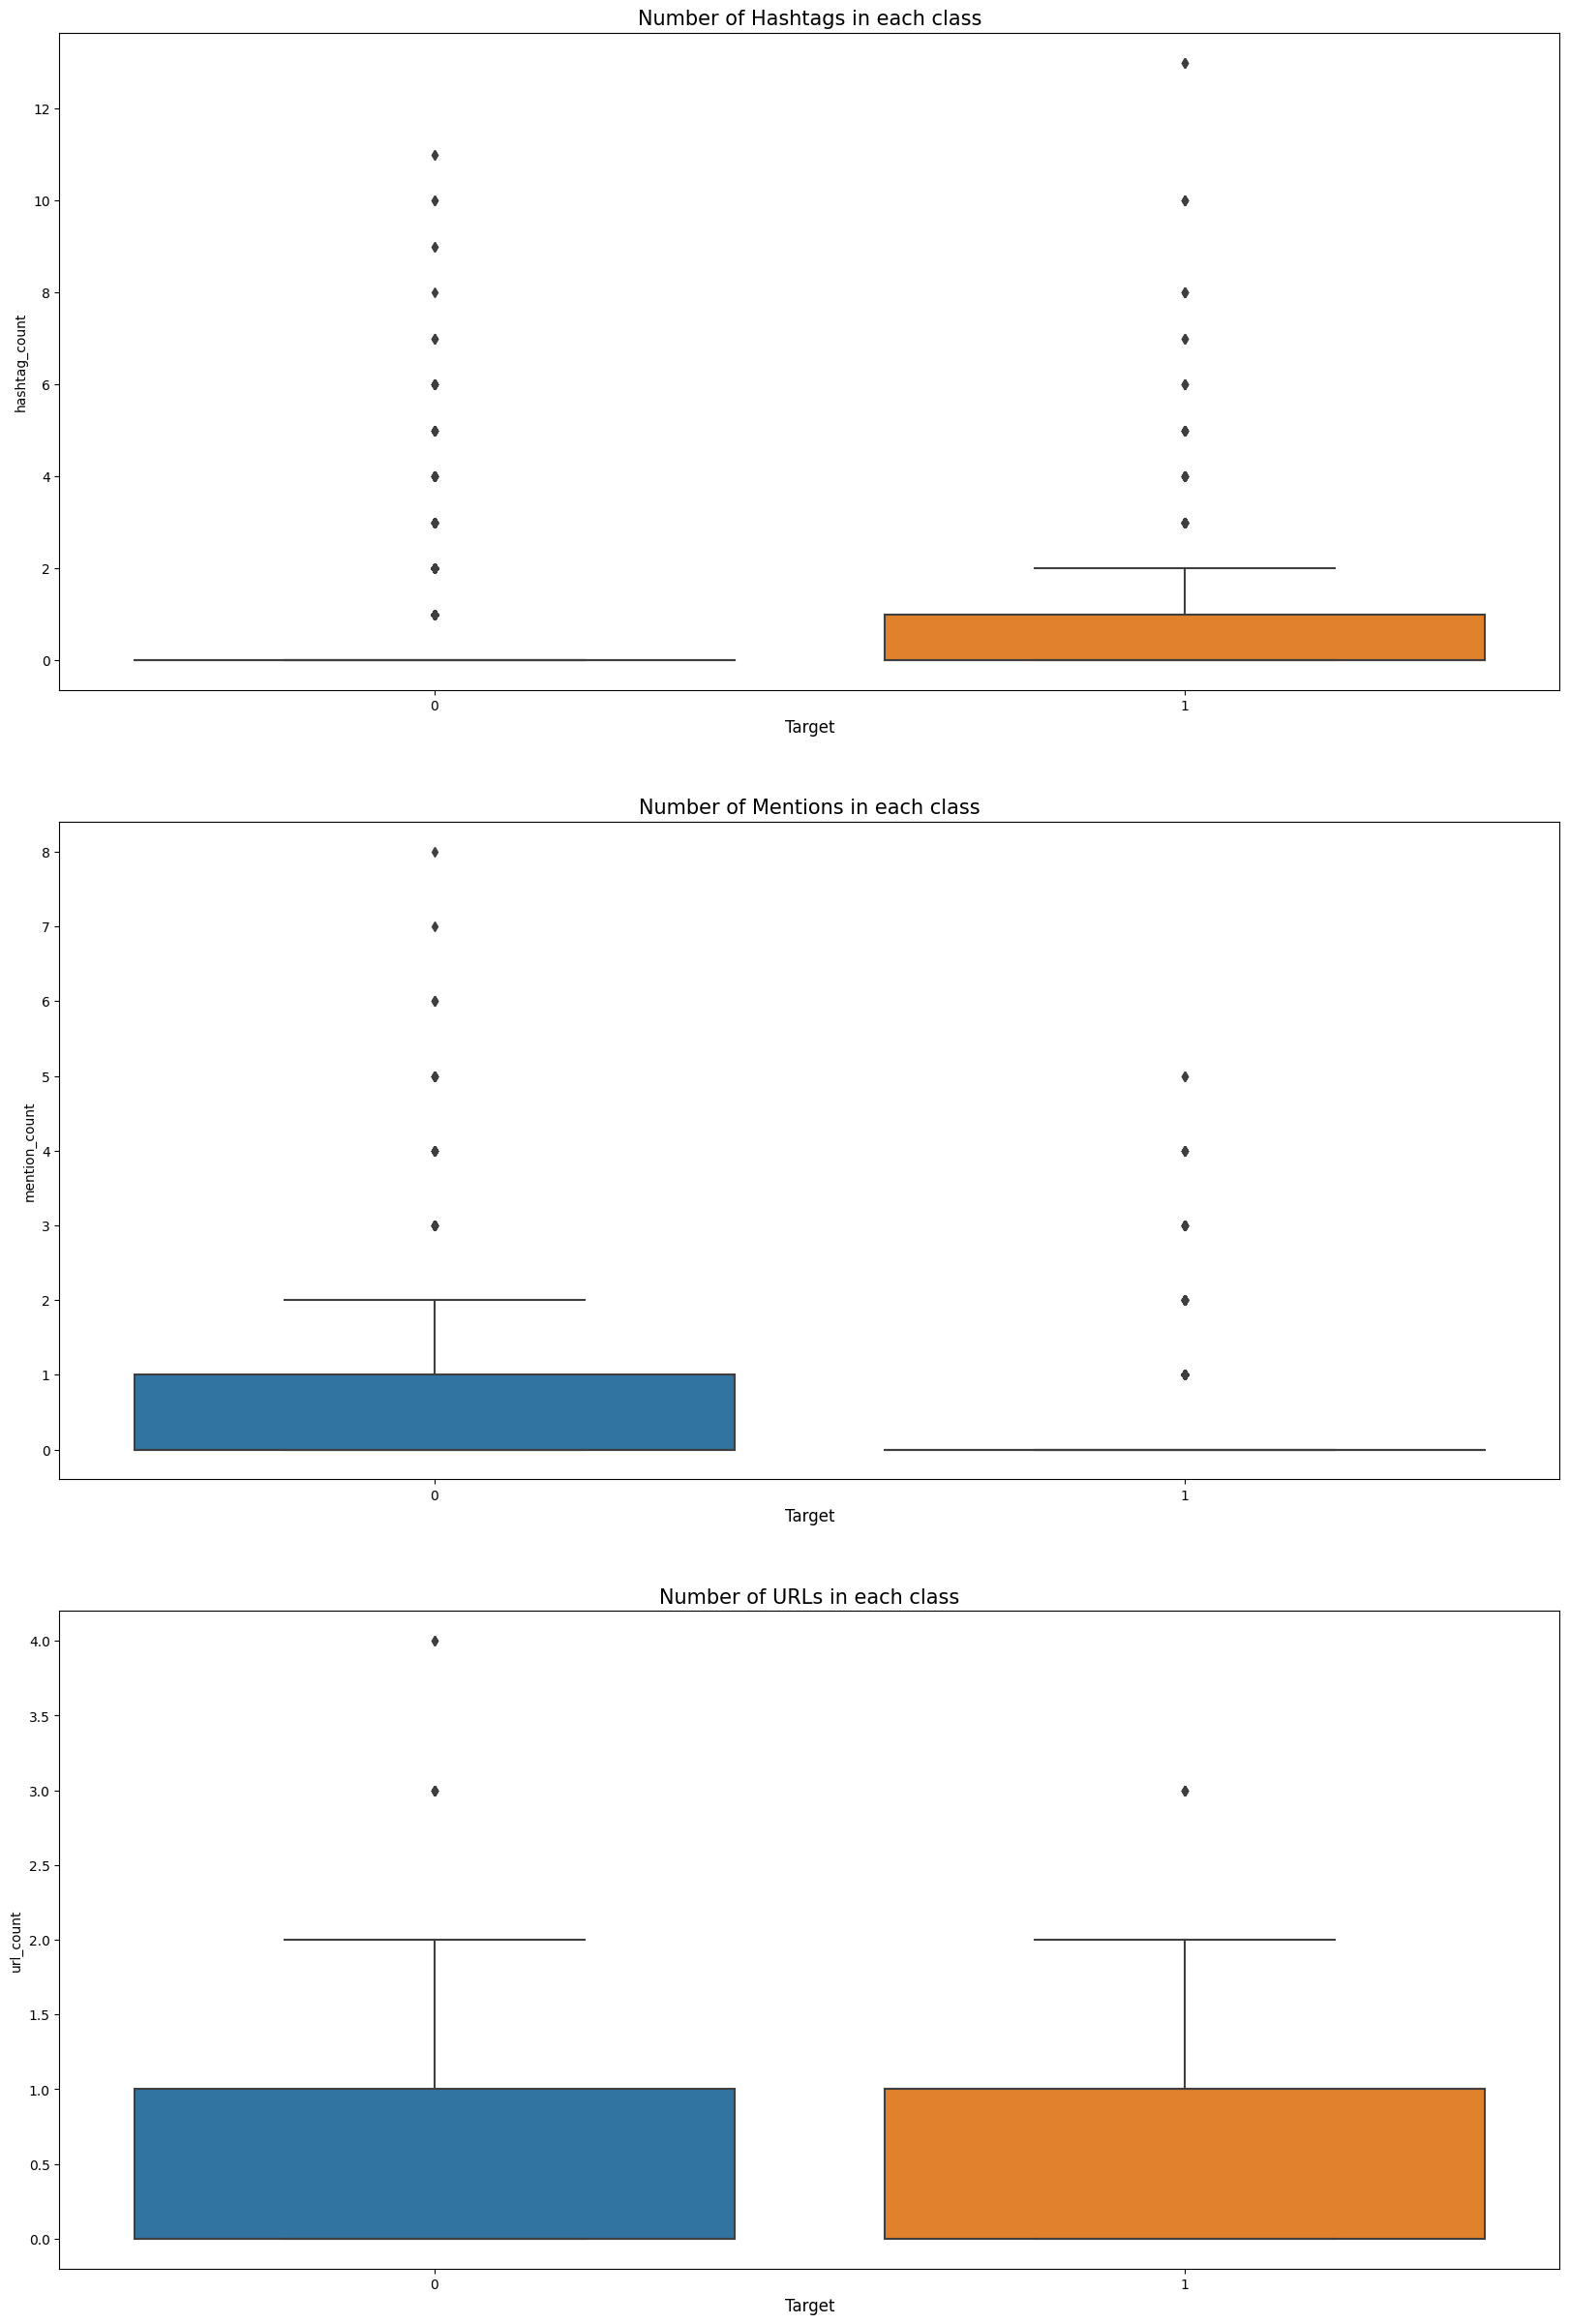

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
df['hashtag_count'].loc[df['hashtag_count']>60] = 60 #truncation for better visuals
df['mention_count'].loc[df['mention_count']>60] = 60 #truncation for better visuals

f, axes = plt.subplots(3, 1, figsize=(20,30))

sns.boxplot(x='target', y='hashtag_count', data=df, ax=axes[0])
axes[0].set_xlabel('Target', fontsize=12)
axes[0].set_title("Number of Hashtags in each class", fontsize=15)

sns.boxplot(x='target', y='mention_count', data=df, ax=axes[1])
axes[1].set_xlabel('Target', fontsize=12)
axes[1].set_title("Number of Mentions in each class", fontsize=15)

sns.boxplot(x='target', y='url_count', data=df, ax=axes[2])
axes[2].set_xlabel('Target', fontsize=12)
axes[2].set_title("Number of URLs in each class", fontsize=15)
plt.show()

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
exclude = string.punctuation
def remove_url(text):
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(r'', text)

def remove_punc(text):
    return text.translate(str.maketrans('', '', exclude))

In [8]:
# --- [CELL 7]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
text1 = 'Check out my notebook https://www.kaggle.com/campusx/notebook8223fc1abb'
text2 = '!hello *world@ 1'
df['text'] = df['text'].apply(remove_url)
#df['text'] = df['text'].apply(remove_punc)
test_df['text'] = test_df['text'].apply(remove_url)
#test_df['text'] = test_df['text'].apply(remove_punc)

In [9]:
# --- [CELL 8]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 9}
from transformers import BertModel, BertTokenizer
import torch
from torch import nn
from torch.utils.data import DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [10]:
# --- [CELL 9]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 10}
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [11]:
# --- [CELL 10]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 11}
example_text = 'I will watch #Memento tonight!'
bert_input = tokenizer(example_text, padding='max_length', max_length = 15,
                      truncation = True, return_tensors = 'pt')

In [12]:
# --- [CELL 11]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 12}
input_ids = torch.tensor(bert_input.input_ids)
attention_mask = torch.tensor(bert_input.attention_mask)
bert_model = BertModel.from_pretrained('bert-base-uncased')
last_hidden_state, pooled_output = bert_model(input_ids=input_ids, attention_mask=attention_mask, return_dict =False)

print(last_hidden_state.shape)
print(bert_model.config.hidden_size)

<ipython-input-12-a45fe10dc4cd>:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  input_ids = torch.tensor(bert_input.input_ids)
<ipython-input-12-a45fe10dc4cd>:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  attention_mask = torch.tensor(bert_input.attention_mask)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

torch.Size([1, 15, 768])
768


In [13]:
# --- [CELL 12]: ---
# cell_state: edited
# execution_status: {'status': 'error', 'done': True, 'execution_count': 13}
# === BEFORE (original) ===
# import tensorflow as tf
# tf.keras.utils.plot_model(bert_model)

# === AFTER (edited) ===
import torch
from torchviz import make_dot

# Visualize the PyTorch BERT model graph instead of using tf.keras.plot_model (TensorFlow-only)
bert_model.eval()
with torch.no_grad():
    outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, return_dict=False)
    last_hidden_state, pooled_output = outputs

dot = make_dot(pooled_output, params=dict(bert_model.named_parameters()))
dot

ModuleNotFoundError: No module named 'torchviz'